# Machine Learning End-to-End

# Look at Big picture & Get the Data

In [1]:
from pathlib import Path
import pandas as pd
import tarfile #  To handle .tgz (compressed tar archive) files
import urllib.request # To download files from the internet

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        # Creates the "datasets" folder (and any parent folders) if it doesn't exist
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        # Downloads the file from the URL and saves it to tarball_path
    with tarfile.open(tarball_path) as housing_tarball:
    # Opens the compressed file safely (the with statement ensures it closes automatically)
        housing_tarball.extractall(path="datasets")
        # Extracts all contents into the "datasets" folder
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

In [2]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Each row represents one district

In [4]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


### Looking at the data
There are 20,640 instances in the dataset, which means that it is fairly small
by machine learning standards, but it’s perfect to get started. 

1. **Notice that the **total_bedrooms** attributes has only 20,433 non-null values. but there are 20,640 instances, which means 207 districts are missing this feature.** You will need to take care of this later
2. All the attributes are numerical, except for **ocean_proximity**. It's type is objcet, so it can hold any kind of python object. But since you loaded
this data from a CSV file, you know that it must be a text attribute.
3. You probably noticed that the values in the
ocean_proximity column were repetitive, which means that it is probably
a categorical attribute.


In [5]:
# You can find out what categories exist and how many districts belong to each category by using the value_counts() method:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


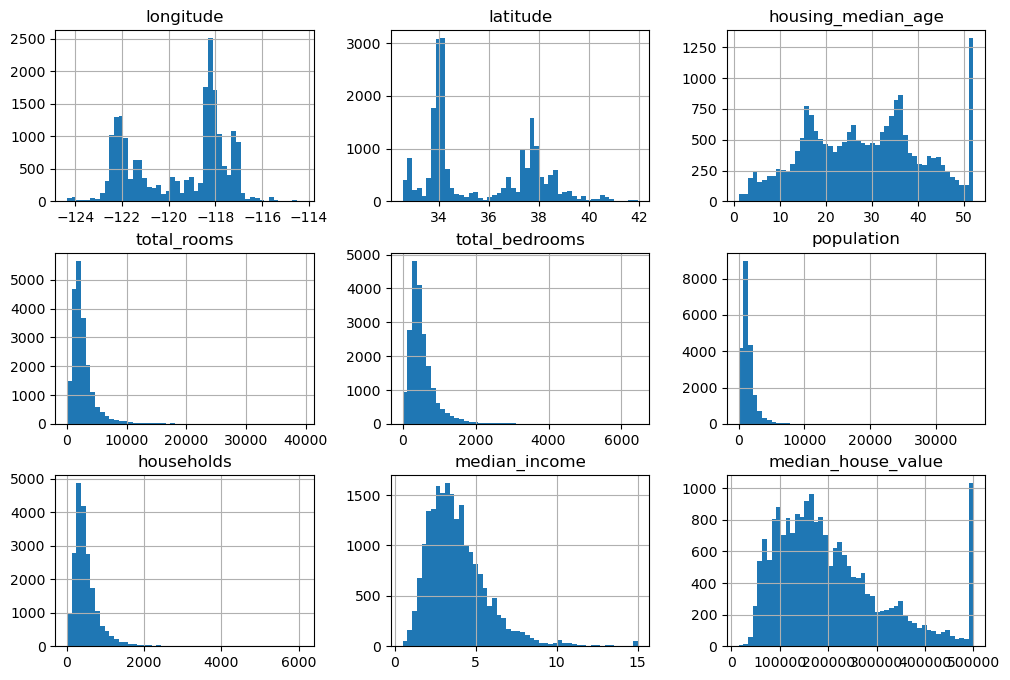

In [7]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(12,8))
plt.show()

**Wait! Before you look at the data any further, you need to create a test set, put it aside,and never look at it.**

Creating a test set is theoretically simple; pick some instances randomly,
typically 20% of the dataset (or less if your dataset is very large), and set
them aside

When building a machine learning model, the most critical rule is to **create a test set and never look at it** to avoid **data snooping bias**, where your brain overfits patterns in the test data before the model even trains. The challenge you've highlighted is how to keep this test set consistent over time as your project evolves.

In [8]:
import numpy as np

def shuffle_and_split_data(dataset, test_ratio):
    np.random.seed(42) # Same shuffle every time
    shuffled_indices = np.random.permutation(len(dataset))
    # indices : plural of index
    
    test_set_size = int(len(dataset) * test_ratio)
    test_indices = shuffled_indices[:test_set_size] 
    train_indices = shuffled_indices[test_set_size:] 
    
    return dataset.iloc[train_indices], dataset.iloc[test_indices]
    



### **The Problem: The "Changing" Test Set**


If you use a simple random split without **random.seed(42)**, **every time you run your code, a different 20% of your data will be picked for testing**. 
*   **The Risk:** If you run the program enough times, your algorithm will eventually "see" every single row in your dataset during training. This defeats the purpose of having a hidden test set for evaluation.
*   **The "Seed" Limitation:** Setting a random seed (like `np.random.seed(42)`) makes the split the same every time you run the *exact same* file. However, **this breaks as soon as you update your dataset** with new rows, because the "shuffled order" changes entirely when the total number of rows increases.
   
### The core problem to solve: 
1. The split looks random (not biased)
2. Each row's assignment never changes, even when you add/remove rows

**The Solution: Hash-Based Splitting**

In [9]:
from zlib import crc32

def assign_id_to_train_and_test(id, test_ratio):
    return crc32(np.int64(id)) < test_ratio * 2**32
    '''
        crc32() produces a random numbers between 0 and 4.29B.
        if That random number is < (0.2 * 4.29).
        Returns True if ID goes to TEST set, False if goes to TRAIN set
    '''

def split_data_in_train_test(dataset, test_ratio, id_column):
    
    ids = dataset[id_column] # ids: plural of id
    in_test_set = ids.apply(lambda id_: assign_id_to_train_and_test(id_, test_ratio))
    # in_test_set contains True/False values for each row in order
    
    return dataset.loc[~in_test_set], dataset.loc[in_test_set]



## Hash Splitting - Step by Step 

**Step 1: Each row needs a permanent, unique ID**
- Use an existing column (student ID, household ID) or create one by combining multiple columns
- This ID must NEVER change, even when the dataset is updated

**Step 2: Pass the ID through crc32() hash function**
- `crc32()` converts the ID into a random-looking number between **0 and 4.29 billion** (2³²)
- Same ID always produces the same hash number, every single time
```
ID: 101 → crc32() → 1,500,000,000
ID: 102 → crc32() → 3,800,000,000
ID: 103 → crc32() →   500,000,000
ID: 104 → crc32() → 2,900,000,000
```

**Step 3: Set a threshold based on test ratio**
- Formula: `threshold = test_ratio × 2³²`
- For 20% test set: `threshold = 0.2 × 4.29B = 858,000,000`
- Numbers **below** threshold → TEST set
- Numbers **above** threshold → TRAIN set

```
0                        858M                      4.29B
|------------------------|-------------------------|
|     TEST (20%)         |      TRAIN (80%)        |
```

**Step 4: Assign each row based on its hash value**
```
ID: 101 → Hash 1.50B → 1.50B > 858M → TRAIN
ID: 102 → Hash 3.80B → 3.80B > 858M → TRAIN
ID: 103 → Hash 0.50B → 0.50B < 858M → TEST
ID: 104 → Hash 2.90B → 2.90B > 858M → TRAIN
```

**Function returns:**
- `True` → ID goes to TEST set (hash < threshold)
- `False` → ID goes to TRAIN set (hash > threshold)

**The assignment is permanent because the hash never changes**


In [10]:
## Method 1

# Unfortunately, the housing dataset does not have an identifier column. 
# The simplest solution is to use the row index as the ID
housing_with_id = housing.reset_index() # adds an `index` column
train_set, test_set = split_data_in_train_test(housing_with_id, 0.2, "index")
'''
 Only works if:
 New data is always appended to the end. because, when id's added or deleted new rows: index shift
'''

"\n Only works if:\n New data is always appended to the end. because, when id's added or deleted new rows: index shift\n"

In [11]:
## Method 2

# Create a stable ID from unchanging features:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]

'''
    A house's location(longitude & latitude) never changes
    Multiplying by 1000 avoids decimal collisions.
    Not perfectly unique, but stable enough for splitting in practice.
'''

"\n    A house's location(longitude & latitude) never changes\n    Multiplying by 1000 avoids decimal collisions.\n    Not perfectly unique, but stable enough for splitting in practice.\n"

In [12]:

# Easier alternative: from sklearn.model_selection import train_test_split
# It does the same random split (shuffle_and_split_data function) plus extra features (stratify, multiple arrays, etc.)
# But for stable splits that don't break when updating the dataset, we use hashing.
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

*   Use **Hashing** if your data is **growing and dynamic**, and you need the split to stay consistent over time.
*   Use **Scikit-Learn (Stratified)** if your data is **limited or unbalanced**

**purely random sampling** can be dangerous for smaller datasets and introduces **stratified sampling** as a more reliable alternative.

### 1. The Problem: Sampling Bias
Population (10,000 people):
- 51.1% Female (5,110 people)
- 48.9% Male (4,890 people)

Random sample of 100 people (by chance):
- 40% Female (40 people) ← Should be 51%!
- 60% Male (60 people)

And Same will happen in Test Train Splitted set.

Result: Your test set doesn't represent reality → Model evaluation is WRONG
**It should be equally distributed on both Test and Train set**

Real-world frequency:
- In production ML: ~30-40% of projects use stratified sampling
- In competitions (Kaggle): Very common for imbalanced targets
- In academic research: Almost always for small datasets

- Large dataset (1M+ rows)-Rarely needed-Random is usually fine due to law of - large numbers
- Small dataset (<10K rows)-Often needed-High chance of random bias
- Time series data-Never-Use time-based split instead

### 2. The Solution: Stratified Sampling
Instead of just picking names out of a hat, you divide the population into homogeneous subgroups called **strata**. It forces the sample to have the exact same proportions as the original.

Train set (80% = 8,000 people from population):
51.1% Female (4,088 people) ✓
48.9% Male (3,912 people) ✓

Test set (20% = 2,000 people from population):
51.1% Female (1,022 people) ✓
48.9% Male (978 people) ✓

### 3. The Housing Example: Median Income
**Experts believe median income is the most important predictor of house prices in California.**

The Problem:
Median income is continuous (1.2, 3.5, 8.9, etc.). You cannot stratify on continuous numbers.

The Solution:
Group incomes into 5 categories using `pd.cut()`:

| Income Range | Category |
|--------------|----------|
| 0.5 - 1.5 | 1 (Very poor) |
| 1.5 - 3.0 | 2 (Poor) |
| 3.0 - 4.5 | 3 (Middle) |
| 4.5 - 6.0 | 4 (Rich) |
| 6.0+ | 5 (Very rich) |

The Rule:
**Each category must have enough data points.**

- Good: 4,000 houses in each category → Stratification works
- Bad: Only 5 very rich houses → Stratification fails

Why This Rule?
If a category is too small:
- Random split might put ALL rich houses in test (or none)
- Test set won't represent rich areas properly



In [13]:
housing["income_cat"] = pd.cut(
    housing["median_income"],          # The continuous column to categorize
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],  # Breakpoints for 5 income buckets
    labels=[1, 2, 3, 4, 5]             # Labels for each bucket
)

'''
    Takes the continuous median_income values (e.g., 0.5, 2.3, 7.1…).
    Sorts each value into one of 5 bins based on the breakpoints:
    Bin 1: $0–$15k → label 1
    Bin 2: $15k–$30k → label 2
    Bin 3: $30k–$45k → label 3
    Bin 4: $45k–$60k → label 4
    Bin 5: $60k+ → label 5
    Creates a new column income_cat with these discrete labels.
    Result: You now have a categorical column you can use for stratified splitting.
'''

'\n    Takes the continuous median_income values (e.g., 0.5, 2.3, 7.1…).\n    Sorts each value into one of 5 bins based on the breakpoints:\n    Bin 1: $0–$15k → label 1\n    Bin 2: $15k–$30k → label 2\n    Bin 3: $30k–$45k → label 3\n    Bin 4: $45k–$60k → label 4\n    Bin 5: $60k+ → label 5\n    Creates a new column income_cat with these discrete labels.\n    Result: You now have a categorical column you can use for stratified splitting.\n'

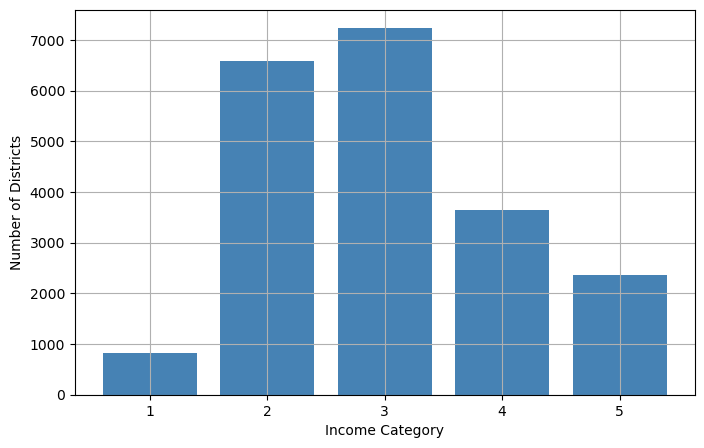

In [14]:
income_counts = housing["income_cat"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(income_counts.index.astype(str), income_counts.values, color='steelblue')

plt.grid(True)
plt.xlabel("Income Category")
plt.ylabel("Number of Districts")
plt.show()

In [15]:
train_set, test_set = train_test_split(housing, 
                                       test_size=0.2, 
                                       random_state=42,
                                       stratify=housing["income_cat"])
# Verify the split worked
print(train_set["income_cat"].value_counts(normalize=True))
print(test_set["income_cat"].value_counts(normalize=True))

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: proportion, dtype: float64
income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: proportion, dtype: float64


The better method to do same is: **`StratifiedShuffleSplit`**  generate multiple pairs (like 10) and why this doesn't cause the problems you're worried about, we need to separate the **initial data split** from the **cross-validation process**.


### Why are 10 splits better than 1?**
If you only use **one** split (a single validation set), you might get "lucky" or "unlucky". 
*   **Accuracy:** By training and evaluating your model 10 different times on 10 different versions of the data, the **average score** gives you a much more accurate estimate of how the model will actually perform on new data.
*   **Precision (Standard Deviation):** Because you have 10 different scores, you can calculate the **standard deviation**. This tells you how much the model's performance "wiggles." If the scores are all very different, you know the model is unstable and you shouldn't trust it.

### **3. Does it require "more rows" for small datasets?**
Actually, it’s the opposite: **Multiple splits (cross-validation) are most useful when your dataset is small**. 
*   In a single split, if you have a small dataset, you have to choose: do I want a big training set (leaving a tiny, unreliable validation set) or a big validation set (leaving too little data for training)?
*   **Cross-validation solves this** because it reuses the same rows. For example, in 10-fold cross-validation, the data is divided into 10 pieces. The model is trained 10 times, each time using a different piece as the "test" and the other 9 pieces for training. 
*   By the end, **every single row** has been used for both training and validation at different points. You aren't adding new rows; you are simply "rotating" the ones you already have to get the most information possible out of them.



In [16]:
'''
This code uses scikit-learn's StratifiedShuffleSplit to create 10 different train/test splits of your housing dataset,
where each split preserves the exact same proportion of income_cat categories as the original data.
It stores all 10 splits in a list, then extracts the first one for immediate use.
'''

from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
# n_splits=10 → Will create 10 different train/test pairs

all_splits=[] # Empty list to store all 10 train/test pairs
for train_idx, test_idx in splitter.split(housing, housing["income_cat"]):
    # train_set_indices_n and test_set_indices_n are just arrays of row numbers for each split.
    
    train_set_n = housing.iloc[train_idx]
    test_set_n = housing.iloc[test_idx]
    all_splits.append([train_set_n, test_set_n]) 

    # say: "For now, you can just use the first split"
strat_train_set, strat_test_set = all_splits[0]


In [17]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

Original Dataset (20,640 districts):
- Middle income (Cat 3) = Most common (~35%)
- Very poor (Cat 1) = Least common (~4%)

Test Set (4,128 districts):
- Same exact pattern!
- Middle income still ~35%
- Very poor still ~4%

✅ Stratification WORKED!

In [18]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# Explore and Visualize the Data to GainInsights

**First, make sure you have put the test set aside and you are only exploring
the training set.  Since you’re going to experiment with
various transformations of the full training set, you should make a copy of
the original so you can revert to it afterwards**

In [19]:
housing = strat_train_set.copy()

### Visualizing Geographical Data

<Figure size 800x500 with 0 Axes>

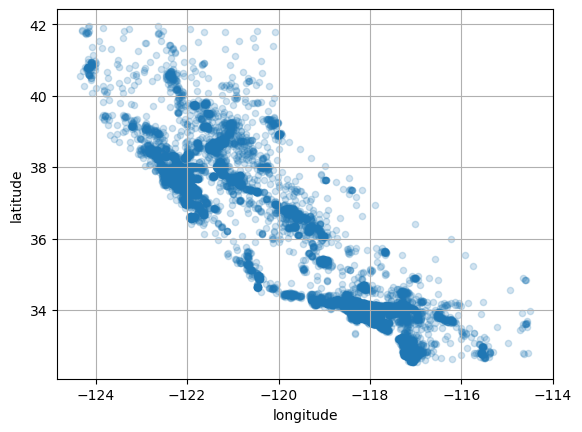

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

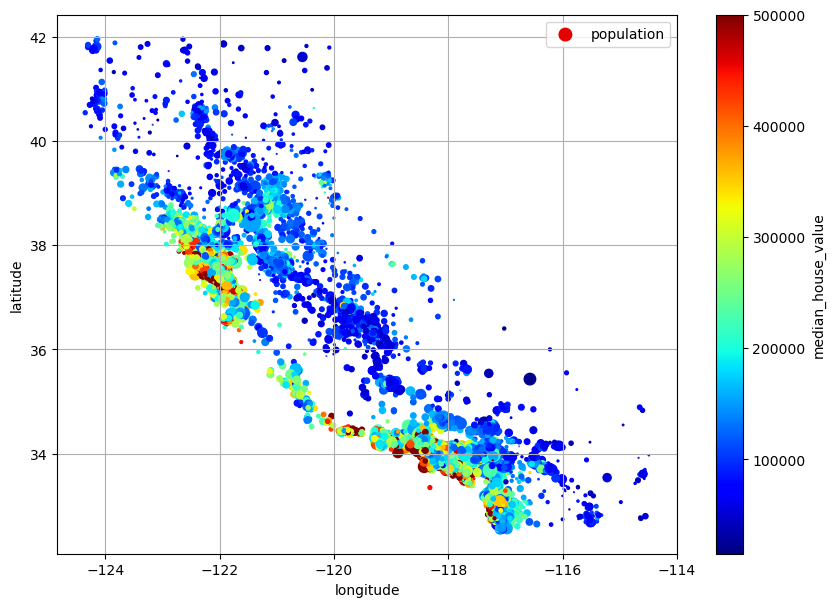

In [21]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, 
            s=housing['population'] / 100, label="population", c="median_house_value", cmap="jet", colorbar=True, legend=True, sharex=False, figsize=(10,7))
plt.show()

In [22]:
# Since the dataset is not too large, you can easily compute the standard correlation coefficient (also called Pearson’s r) between every pair of attributes using the corr() method

In [23]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN


In [24]:
corr_matrix= housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

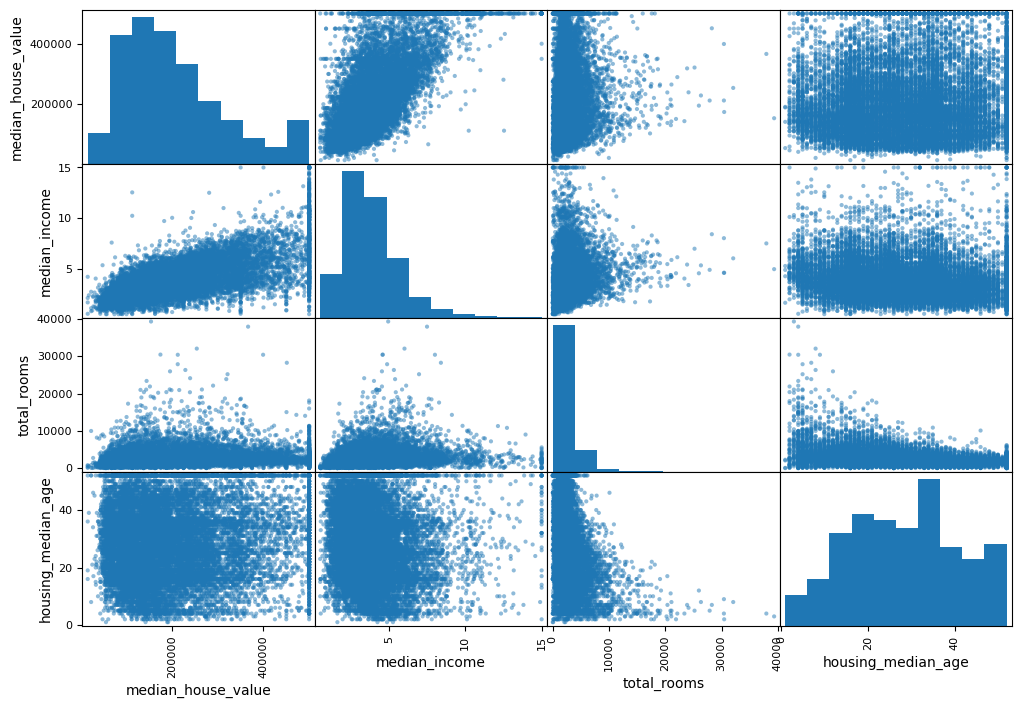

In [25]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

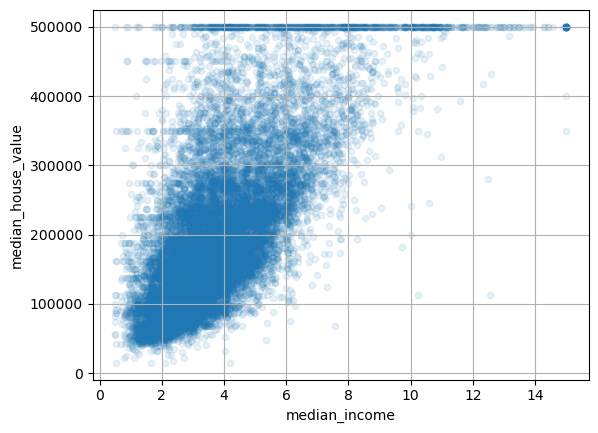

In [26]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True)
plt.show()

In [27]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [28]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

# Prepare the Data for Machine Learning Algorithms

**It’s time to prepare the data for your machine learning algorithms. Instead
of doing this manually, you should write functions for this purpose, for
several good reasons:**
1. This will allow you to reproduce these transformations easily on any dataset (e.g., the next time you get a fresh dataset).
2. You will gradually build a library of transformation functions that you can reuse in future projects.
3. You can use these functions in your live system to transform the new data before feeding it to your algorithms.
4. This will make it possible for you to easily try various transformations and see which combination of transformations works best.

**But first, revert to a clean training set (by copying strat_train_set once
again). You should also separate the predictors and the labels, since you
don’t necessarily want to apply the same transformations to the predictors
and the target values (note that drop() creates a copy of the data and does
not affect strat_train_set)**

In [29]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

### Clean the Data
**Most machine learning algorithms cannot work with missing features, so
you’ll need to take care of these. For example, total_bedrooms because it is the only attribute in your dataset with missing values (207 districts are missing this information. You have three options
to fix this:**

- Option 1: Drop the Districts (Rows). You can simply delete the 207 rows where the data is missing. This is done using the dropna() method.

- Option 2: Drop the Attribute (Column). You can remove the total_bedrooms feature entirely from your project. This is done using the drop() method.

- Option 3: Imputation (Fill the Gaps). You can fill the missing spots with a specific value, such as the median, mean, or zero. The author chooses this option because it is the "least destructive"—you keep all your rows and your features while making the data complete.z


housing.dropna(subset=["total_bedrooms"], inplace=True) **# option1**
housing.drop("total_bedrooms", axis=1) **# option2**

median = housing["total_bedrooms"].median() **#option 3**
housing["total_bedrooms"].fillna(median, inplace=True)

In [30]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")



**The Professional Solution: `SimpleImputer`**
This tool is superior to a simple manual fix (like Pandas' fillna()) because it ensures consistency across your entire project.

The benefit is that it will store the median value of each feature: this will make it possible to impute missing values not only on the training set, but also on the validation set, the test set, and any new data fed to the model. To use it, first you need to create a SimpleImputer instance, specifying that you want to replace each attribute’s missing values with the median of that attribute


In [31]:
housing_num = housing.select_dtypes(include=[np.number])
# Since the median can only be computed on numerical attributes

imputer.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


**The imputer has simply computed the median of each attribute and stored
the result in its statistics_ instance variable. Only the total_bedrooms
attribute had missing values, but you cannot be sure that there won’t be any
missing values in new data after the system goes live, so it is safer to apply
the imputer to all the numerical attributes**

In [32]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [33]:
housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [34]:
# Now, you call imputer.transform(housing_num), which actually replaces the missing values in the dataset with the medians it just learned
X = imputer.transform(housing_num)


Missing values can also be replaced with the mean value
- (strategy="mean"), or with the most frequent value
- (strategy="most_frequent"), or with a constant value
- (strategy="constant", fill_value=…).
- The last two strategies support
non-numerical data.


**There are also more powerful imputers available in the sklearn.impute package (both for numerical features only):**
- **KNNImputer** replaces each missing value with the mean of the k-nearest
neighbors’ values for that feature. The distance is based on all the available
features.
- **IterativeImputer** trains a regression model per feature to predict the missing
values based on all the other available features. It then trains the model again on
the updated data, and repeats the process several times, improving the models and
the replacement values at each iteration.

In [35]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

### Handling Text and Categorical Attributes

In [36]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


**It’s not arbitrary text: there are a limited number of possible values, each of which represents a category. So this attribute is a categorical attribute.**

Most machine learning algorithms prefer to work with numbers, so let’s convert
these categories from text to numbers. For this, we can use Scikit-Learn’s
OrdinalEncoder class

In [37]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [38]:
housing_cat_encoded

array([[3.],
       [0.],
       [1.],
       ...,
       [4.],
       [0.],
       [4.]], shape=(16512, 1))

In [39]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]


### 1. The Problem with Numbers (Ordinal Encoding)
When we used the `OrdinalEncoder`, it turned the categories in `ocean_proximity` into a single column of numbers:
*   `<1H OCEAN` → **0**
*   `INLAND` → **1**
*   `ISLAND` → **2**
*   `NEAR BAY` → **3**
*   `NEAR OCEAN` → **4**

The issue is that **machine learning algorithms assume that two nearby values are more similar than two distant values**. Mathematically, the model thinks 0 is "closer" to 1 than it is to 4. 

However, in our housing data, `<1H OCEAN` (0) is actually much more similar to `NEAR OCEAN` (4) than it is to `INLAND` (1). Using simple numbers tricks the model into making false assumptions about the relationships between locations.

### 2. The Solution: One-Hot Encoding
To fix this, we create **one binary attribute per category**. These are often called **dummy attributes**.
*   Instead of one column with five different numbers, we get **five separate columns** (one for each category).
*   For any given row, only the column representing its category will be **1 (Hot)**, while all others will be **0 (Cold)**.

**How a district that is "INLAND" would look after encoding:**

| `<1H OCEAN` | `INLAND` | `ISLAND` | `NEAR BAY` | `NEAR OCEAN` |
| :--- | :--- | :--- | :--- | :--- |
| 0 | **1** | 0 | 0 | 0 |

Because every category now has its own column, the model no longer tries to "compare" them numerically. It just sees whether a specific condition (like being Inland) is **True (1)** or **False (0)**.


In [40]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [41]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [42]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

### 1. The Problem: Data Mismatch
Imagine you train your model on five categories for `ocean_proximity` (like `<1H OCEAN`, `INLAND`, etc.). When your model goes into production, a user might enter a new, unexpected category like `"<2H OCEAN"`.
*   **The risk with simple tools:** A function like Pandas' `get_dummies()` would simply create a brand-new column for this new category. This would change the shape of your data, causing your machine learning model to crash because it only knows how to handle the original five columns.

### 2. How `OneHotEncoder` is "Smarter"
The Scikit-Learn `OneHotEncoder` **remembers** exactly which categories it saw during training. When it encounters a category it doesn't recognize:

*   **The Default Behavior (Raise an Exception):** By default, it will stop your program and raise an error. This is useful because it alerts you immediately that your new data contains something your model wasn't prepared for.
*   **The "Ignore" Option:** If you set the hyperparameter **`handle_unknown="ignore"`**, the encoder will not crash. Instead, for that specific row, it will set **all the category columns to 0**.


In [43]:
df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})
pd.get_dummies(df_test_unknown)

,ocean_proximity_<2H OCEAN,ocean_proximity_ISLAND
0,True,False
1,False,True


In [44]:
cat_encoder.handle_unknown = "ignore"
cat_encoder.transform(df_test_unknown)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1 stored elements and shape (2, 5)>

In [45]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [46]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [47]:
encoded_data = cat_encoder.transform(df_test_unknown).toarray()
df_output = pd.DataFrame(
    encoded_data,
    columns=cat_encoder.get_feature_names_out(),
    index=df_test_unknown.index
)

### Feature Scaling and Transformation

In a machine learning project, feature scaling is one of the most vital steps in data preparation because most algorithms do not perform well when input numerical attributes have very different scales.

In the California housing dataset, for instance, the total_rooms range from 6 to 39,320, while median_income only ranges from 0 to 15. Without scaling, many models will be biased, often ignoring the smaller-scale income values and focusing disproportionately on the number of rooms.



### **Two Common Scaling Methods**
There are two primary ways to bring all attributes to the same scale:

*   **Min-Max Scaling (Normalization):** This shifts and rescales values so they typically range from 0 to 1. It is performed by subtracting the minimum value and dividing by the difference between the min and max. Scikit-Learn provides the **`MinMaxScaler`** for this, which also allows you to choose a custom range (like –1 to 1, which neural networks often prefer).
*   **Standardization:** This subtracts the mean (resulting in a zero mean) and divides by the standard deviation (resulting in a unit variance). Unlike min-max scaling, it does not restrict values to a specific range, but it is **much less affected by outliers**. For example, if a data error gives a district a median income of 100 instead of 15, standardization will not "crush" all other values as severely as min-max scaling would. Scikit-Learn provides **`StandardScaler`** for this.



In [48]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1,1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [49]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

In [50]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

This code snippet demonstrates an advanced feature engineering technique used to handle **multimodal distributions** (data with multiple peaks). It uses a **Gaussian Radial Basis Function (RBF)** to create a new feature based on the "similarity" between the data and a specific landmark.

Here is a breakdown of what the code is doing and why:

### **1. The Goal: Highlighting a Specific Peak**
In the housing dataset, the `housing_median_age` distribution has several spikes. One of these spikes occurs around age 35. Sometimes, specific values have a unique impact on the target (e.g., maybe houses built exactly 35 years ago have an architectural style that is currently unpopular, making them cheaper). 

Standard scaling or simple linear models might miss this "local" quirk. This code creates a feature that tells the model: **"How close is this specific house to being 35 years old?"**.

### **2. Breakdown of the Code**
*   **`rbf_kernel(...)`**: This function calculates a similarity score between your data and a chosen "landmark".
*   **`housing[["housing_median_age"]]`**: This is the input data (the ages of all houses in your training set).
*   **`[]`**: This is the **landmark**. You are telling the function to compare every house age in the dataset to the value 35.
*   **`gamma=0.1`**: This hyperparameter ($\gamma$) defines how "narrow" or "wide" the peak is. 

### **3. How the Output Works**
The result, `age_simil_35`, is a new numerical column where the values range from **0 to 1**:
*   **Value is 1.0**: The house is exactly 35 years old (perfect similarity).
*   **Value is near 0.0**: The house age is very far from 35.
*   **Exponential Decay**: The similarity score drops off following a bell-shaped (Gaussian) curve as you move away from 35.

### **4. The Role of $\gamma$ (Gamma)**
As mentioned in our previous conversation, you can control the "width" of this bell curve:
*   **High Gamma (e.g., 0.10)**: Creates a **narrower** peak. Only houses very close to age 35 will have a high similarity score.
*   **Low Gamma (e.g., 0.03)**: Creates a **wider, smoother** curve. Houses that are 30 or 40 years old might still have a moderately high similarity score.

### **Summary**
Instead of just telling the model "the house is $X$ years old," this code adds a specific signal: "This house is very similar to the 35-year-old group". This allows the model to more easily learn different rules for specific age ranges that might otherwise be hidden in the data.

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. Scale the target (house prices)
target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

# 2. Train the model
model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)

# 3. Predict on new data
some_new_data = housing[["median_income"]].iloc[:5]  # pretend this is new data
scaled_predictions = model.predict(some_new_data)

# 4. Convert predictions back to original scale ($)
predictions = target_scaler.inverse_transform(scaled_predictions)
print(predictions)

[[131997.15275877]
 [299359.35844434]
 [146023.37185694]
 [138840.33653057]
 [192016.61557639]]


This code demonstrates a specific technique called **target scaling**, where you standardize not just your input features (like `median_income`), but also the labels your model is trying to predict (`housing_labels`).

Here is a step-by-step breakdown of what the code is doing:

### **1. Scaling the Labels**
```python
target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())
```
*   **The Action:** It takes the house prices (labels) and standardizes them so they have a mean of 0 and a standard deviation of 1.
*   **Why `.to_frame()`?** Scikit-Learn's `StandardScaler` expects a 2D input (like a table), but `housing_labels` is typically a 1D Pandas Series. This method converts it into the 2D format the scaler needs.
*   **The Goal:** Some models perform better when the target values are on a similar scale to the input features.

### **2. Training the Model**
```python
model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
```
*   **The Action:** It trains a linear regression model using only one predictor: `median_income`.
*   **The Key Detail:** The model is learning to predict the **scaled** house values, not the actual dollar amounts. If a house is worth \$500,000, the model is currently learning to predict its standardized version (e.g., 2.5).

### **3. Making Predictions**
```python
some_new_data = housing[["median_income"]].iloc[:5]
scaled_predictions = model.predict(some_new_data)
```
*   **The Action:** You feed new "median income" data into the model.
*   **The Result:** The model outputs **scaled predictions**. For example, instead of saying a house costs \$200,000, it might output `-0.5`. This number is mathematically correct according to the scaled space but is not useful for a human who needs to know the price in dollars.

### **4. Reversing the Scaling**
```python
predictions = target_scaler.inverse_transform(scaled_predictions)
```
*   **The Action:** This is the most critical step. It uses the `target_scaler`'s **`inverse_transform()`** method to "un-standardize" the results.
*   **The Result:** It converts those weird standardized numbers (like `-0.5`) back into **actual dollar amounts** (like \$185,000) based on the mean and standard deviation it learned in the first step.

### **Summary of the Big Picture**
This code allows your model to work with "easy" standardized numbers during the training phase, while still providing results in **original units (dollars)** for the final user.

**Note on Efficiency:** The book mentions that while this manual process works, Scikit-Learn provides a cleaner tool called **`TransformedTargetRegressor`** that automates the `fit`, `transform`, and `inverse_transform` steps for you in a single object.

**This is scikit-learn shortcut that automates the entire "scale labels → train → predict → unscale" workflow into a single, clean object.**



In [52]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(
    LinearRegression(),
    transformer=StandardScaler()
)

model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)

### Custom Transformers

In [53]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing["population"])



In [54]:
rbf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[[35.]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])

In [55]:
sf_coords = 37.7749, -122.41 # This defines the landmark (the exact latitude and longitude of San Francisco)
sf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[sf_coords], gamma=0.1))
sf_simil = sf_transformer.transform(housing[["latitude", "longitude"]])

In [56]:
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
ratio_transformer.transform(np.array([[1., 2.], [3., 4.]]))

array([[0.5 ],
       [0.75]])

In [57]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):
        self.with_mean = with_mean

    def fit(self, X, y=None): #y is required even though we dont use it
        X =Check_array(X) # checks that X is an array with finite float values
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1]

        return self # alway return self

    def Transform(self, X):
        check_is_fitted(self) # looks for learned attributes (with trailing)

        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_
        
    

In [58]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
   
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
      
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

  
    def transform(self, X):
       
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    # FIX 5: Un-indent this too
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]


In [59]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(
    housing[["latitude", "longitude"]], 
    sample_weight=housing_labels
)

# Let's look at the first 3 rows, rounding to two decimal places
print(similarities[:3].round(2))

[[0.08 0.   0.6  0.   0.   0.99 0.   0.   0.   0.14]
 [0.   0.99 0.   0.04 0.   0.   0.11 0.   0.63 0.  ]
 [0.44 0.   0.3  0.   0.   0.7  0.   0.01 0.   0.29]]


### Transformation Pipelines

In [60]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler())
])

In [61]:
import sklearn
sklearn.set_config(display="diagram")

In [62]:
num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute', ...), ('standardize', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If

In [63]:
from sklearn.pipeline import make_pipeline
num_pipeline = make_pipeline(
    (SimpleImputer(strategy="median")),
     (StandardScaler())
)

In [64]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [65]:
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
    index=housing_num.index
)

In [66]:
from sklearn.compose import ColumnTransformer


# 1. Define the column names
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms", 
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]


# 3. Define the Categorical Pipeline
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

# 4. The Master Router: ColumnTransformer
preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])


### **1. `make_column_selector()`: Automatic Column Selection**
In a real-world dataset with dozens or hundreds of columns, it is very inconvenient to manually type out a list of every single numerical or categorical column name.
*   **What it does:** It creates a small "helper" function that scans your dataset and picks out columns based on their **data type**.
*   **How you use it:** You can tell it to include only numbers (`dtype_include=np.number`) or only text/objects (`dtype_include=object`).
*   **The Benefit:** You don't have to worry about missing a column or updating your code if a new column of the same type is added to your data later; the selector finds it automatically.

### **2. `make_column_transformer()`: The Shortcut for Pipelines**
Just as `make_pipeline()` is a shortcut for `Pipeline`, **`make_column_transformer()`** is a shortcut for building a `ColumnTransformer`.
*   **Automatic Naming:** In a standard `ColumnTransformer`, you are required to give every step a unique name (like "num" or "cat"). With `make_column_transformer()`, you skip this step. Scikit-Learn chooses the names for you automatically.
*   **The Naming Rule:** It typically uses a format like `"pipeline-1"`, `"pipeline-2"`, etc., based on the order of the transformers you provided.



In [67]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

In [68]:
housing_prepared = preprocessing.fit_transform(housing)

In [69]:
preprocessing.get_feature_names_out()

array(['pipeline-1__longitude', 'pipeline-1__latitude',
       'pipeline-1__housing_median_age', 'pipeline-1__total_rooms',
       'pipeline-1__total_bedrooms', 'pipeline-1__population',
       'pipeline-1__households', 'pipeline-1__median_income',
       'pipeline-2__ocean_proximity_<1H OCEAN',
       'pipeline-2__ocean_proximity_INLAND',
       'pipeline-2__ocean_proximity_ISLAND',
       'pipeline-2__ocean_proximity_NEAR BAY',
       'pipeline-2__ocean_proximity_NEAR OCEAN'], dtype=object)

This is the stage of the project where you **consolidate all your individual experiments into one master preprocessing object**.

Instead of running multiple separate code cells to transform your data, you are creating a single `ColumnTransformer` that acts as an **"automated cleaning machine"** for your entire dataset. Here is exactly what is happening in this "one big code" phase:

### **1. Why unify everything?**
Up to this point, the book has had you experiment with different techniques (like log transforms or cluster similarities) one by one to see what works. Now, you are building a **production-ready pipeline** so that:
*   **Consistency:** You can apply the exact same complex math to your training set, your test set, and any future new data with a single command (`fit_transform`).
*   **Automation:** When you are ready to train models, you can just plug this master `preprocessing` object into a final `Pipeline` with a model (like Linear Regression), and the data will be cleaned and predicted in one go.

### **2. How the "Master Code" is Structured**
The "big code" (found in passages and) uses a **`ColumnTransformer`** to orchestrate different transformations on different columns simultaneously. It is organized into a list of "triplets": **(Name, Transformer/Pipeline, Columns)**.

Here is how it handles the six tasks you recapped:

*   **Ratio Features:** It uses a custom `ratio_pipeline()` to calculate `bedrooms_ratio`, `rooms_per_house`, and `people_per_house`. These are added because they often correlate better with house prices than raw counts.
*   **Log Transformations:** It applies a `log_pipeline` to features with "long tails" (like `population` or `median_income`). This squashes the distribution into a bell shape that is easier for models to learn from.
*   **Cluster Similarity:** It uses the `ClusterSimilarity` custom class you built earlier to turn latitude and longitude into 10 "similarity scores" based on geographic hubs. This is much more useful to a model than raw coordinates.
*   **Categorical Encoding:** It uses a `cat_pipeline` to fill missing text values and then apply **One-Hot Encoding** so the model can process the `ocean_proximity` data as numbers.
*   **Standardization & Imputation:** Every numerical pipeline includes a `SimpleImputer` (to fill missing values with the median) and a `StandardScaler` (to ensure all numbers are on the same scale, usually -1 to 1 or 0 to 1).
*   **The "Remainder":** There is one column left over—`housing_median_age`. The code uses a `remainder` argument to apply a `default_num_pipeline` to it so that it is also imputed and scaled without any other special transforms.

### **3. The Final Result**
When you run this consolidated code, your original 10 columns are transformed into a single NumPy array with **24 highly informative features**. 

Instead of a messy folder of different transformation scripts, you now have **one professional object** (`preprocessing`) that handles all the complexity of your data preparation automatically. This allows you to focus on the next step: **selecting and training the actual machine learning models**.

In [70]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"] 

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
],
remainder=default_num_pipeline) # one column remaining: housing_median_age

    

In [71]:
housing_prepared = preprocessing.fit_transform(housing)


In [72]:
housing_prepared.shape

(16512, 24)

In [73]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

# Select and Train a Model

**At last! You framed the problem, you got the data and explored it, you
sampled a training set and a test set, and you wrote a preprocessing pipeline
to automatically clean up and prepare your data for machine learning
algorithms. You are now ready to select and train a machine learning model**

### Train and Evaluate on the Training Set

In [74]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: fl

Done! You now have a working linear regression model. You try it out on
the training set, looking at the first five predictions and comparing them to
the labels:

In [75]:
housing_predictions = lin_reg.predict(housing)

In [76]:
housing_predictions[:5].round(-2) # rounds to the nearest hundred.

array([242800., 375900., 127500.,  99400., 324600.])

In [77]:
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])



### 1. The Manual Check (Why it's misleading)
First, let's look at the two arrays you printed:

**Array 1: The Model's Guesses (`housing_predictions`)**
`[242800., 375900., 127500., 99400., 324600.]`

**Array 2: The Actual Truth (`housing_labels`)**
`[458300., 483800., 101700., 96100., 361800.]`

If you compare them side-by-side:
*   **House 1:** Guessed \$242k, Actual \$458k. **(Terrible! Off by \$215,000!)**
*   **House 2:** Guessed \$375k, Actual \$483k. **(Bad. Off by \$100,000.)**
*   **House 3:** Guessed \$127k, Actual \$101k. **(Okay. Off by \$25k.)**
*   **House 4:** Guessed \$99k, Actual \$96k. **(Great! Off by only \$3k.)**

**The Problem:** If you only look at a few random rows, your brain will play tricks on you. You might look at House 4 and think, *"Wow, it's only off by \$3,000, this model is a genius!"* But then you look at House 1 and realize it's off by a massive \$215,000. 

You cannot judge a model by looking at 5 houses out of 17,000. You need a mathematical formula that looks at **all 17,000 houses at the exact same time** and gives you one single "Error Score."

---

### 2. The Official Score: RMSE
**RMSE** stands for **Root Mean Squared Error**. 
In plain English, RMSE answers this question: **"On average, how many dollars is my model off by?"**


In [78]:

from sklearn.metrics import root_mean_squared_error
lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)

In [79]:
lin_rmse

68647.95686706662


### 1. The "Ruler" Analogy
Imagine the "normal" price of a house is measured on a ruler that goes from **$120k** to **$265k**.
*   The total length of that ruler is **$145,000**. (265-120)
*   Your model’s average error is **$68,648**.

**Your error is almost HALF the size of the entire ruler.**
If you try to point to a specific house on that ruler, your model is likely to miss it by such a wide margin that it lands in a completely different neighborhood.

Being off by **35% to 50%** on a financial asset is a disaster. If you were a bank using this model to approve mortgages, you would lose millions of dollars because your valuations are completely unreliable.

### 3. The Diagnosis: "Underfitting"
In Machine Learning, when a model is this far off on the training data, we say it is **Underfitting**.

*   **What it means:** The model is **too simple** to capture the complexity of the data.


The main ways to fix underfitting are :
- to select a more powerful model
- to feed the training algorithm with better features
- or to reduce the constraints on the model.

This model is not regularized, which rules out the last option. You could try
to add more features, but first you want to try a more complex model to see
how it does

**you decide to try a DecisionTreeRegressor, as this is a fairly powerful
model capable of finding complex nonlinear relationships in the data**

In [80]:
from sklearn.tree import DecisionTreeRegressor 

tree_reg = make_pipeline(
    preprocessing, 
    DecisionTreeRegressor(random_state=42)
)

tree_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshol

Now that the model is trained, you evaluate it on the training set:

In [81]:
housing_predictions = tree_reg.predict(housing)

In [82]:
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)

In [83]:
tree_rmse

0.0


### **1. Why move beyond simple training evaluation?**
In the previous step, your **Decision Tree** model produced an RMSE of **0.0**, appearing to be "perfect". However, this is almost certainly **overfitting**, where the model has memorized the training data rather than learning general patterns. Cross-validation allows you to catch this without touching your "sacred" test set.

### **2. How $k$-fold Cross-Validation Works**
Instead of just splitting your data once, this technique performs multiple mini-experiments:
*   **The Split:** The training set is randomly divided into 10 nonoverlapping subsets called **folds**.
*   **The Loop:** The model is trained and evaluated **10 times**. Every time, a different fold is held out for evaluation, while the model trains on the other 9 folds.
*   **The Result:** You end up with an array of 10 evaluation scores.


### Better Evaluation Using Cross-Validation

In [84]:
from sklearn.model_selection import cross_val_score

In [85]:
tree_rmses = -cross_val_score(tree_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)

In [86]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     67153.318273
std       1963.580924
min      63925.253106
25%      66083.277180
50%      66795.829871
75%      68074.018403
max      70664.635833
dtype: float64

**Now the decision tree doesn’t look as good as it did earlier. In fact, it seems to perform almost as poorly as the linear regression model!**

In [87]:
lin_rmses = -cross_val_score(lin_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)

In [88]:
pd.Series(lin_rmses).describe()

count       10.000000
mean     69847.923224
std       4078.407329
min      65659.761079
25%      68088.799156
50%      68697.591463
75%      69800.966364
max      80685.254832
dtype: float64

**Let’s try one last model now: the RandomForestRegressor**

In [89]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)

In [90]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     47002.931706
std       1048.451340
min      45667.064036
25%      46494.358345
50%      47093.173938
75%      47274.873814
max      49354.705514
dtype: float64

The Random Forest just dropped the error by over $20,000!

Instead of guessing the price of a house and being off by ~$68,000, 

your model is now only off by ~$47,000. In the world of machine learning, this is a massive improvement. You have successfully moved from a "bad" model to a "decent/usable" model.

### Look at the Mean RMSE (The Typical Error)**
The **Root Mean Square Error (RMSE)**  It tells you, on average, how many dollars the model's prediction is away from the actual house price.
*   **Linear Regression:** Had a mean cross-validation RMSE of **$69,858**.
*   **Decision Tree:** Had a mean cross-validation RMSE of **$66,868**.
*   **Random Forest:** Had a mean cross-validation RMSE of **$47,019**.

**How to compare:** You can see that the Random Forest is "off" by about **$20,000 less** than the other two models. While the Decision Tree performs slightly better than Linear Regression, the book notes that the difference is "minimal".

### Compare the Error to the House Prices (The "How Bad" Factor)**
To understand "how much it is off" in a real-world sense, you must compare the error to the actual values you are trying to predict.
-   The source mentions that most median house values in the districts range between **$120,000 and $265,000**.
-   **Linear Regression/Decision Tree:** An error of ~$68,000 on a $120,000 house means the model is off by **over 50%**. This is why the book describes these scores as "really not very satisfying".
-   **Random Forest:** An error of ~$47,000 is still significant, but it represents a much smaller percentage of the total house value, making it a much more "promising" model.

###  Look at the Standard Deviation (The Consistency)**
Cross-validation provides a **standard deviation (std)**, which tells you how much the error fluctuated across different parts of your data.
-   **Linear Regression:** $69,858 ± 4,182.

-   **Decision Tree:** $66,868 ± 2,061.

-   **Random Forest:** $47,019 ± 1,033.

**How to compare:** A lower standard deviation means the model is more **consistent**. The Random Forest not only has the lowest error but also the lowest fluctuation ($1,033), meaning it is more reliable across different subsets of data.

### Check for Overfitting**
You can also compare the **Training Error** against the **Validation (Cross-Validation) Error** to see if the model is just "memorizing" data.
*   **Decision Tree:** Its training error was **0.0** (perfect), but its validation error was **$66,868**. This massive gap proves it was **severely overfitting**.
  
*   **Random Forest:** Its training error was $17,474

while its validation error was $47,019.

*   There is still quite lot of overfitting here, but because the validation score is so much lower than the other models, it is objectively the "winner" of this stage. possible solutions are to
simplify the model, constrain it (i.e., regularize it), or get a lot more training
data. 



# Fine-Tune Your Model

In the **Fine-Tune Your Model** stage of a machine learning project, **Grid Search** is a powerful technique used to automatically find the best combination of hyperparameters for your model. Instead of manually fiddling with settings—which is tedious and time-consuming—you can use Scikit-Learn’s **`GridSearchCV`** class to handle the heavy lifting for you.

### How It Works
When you use Grid Search, you provide a "grid" of hyperparameters you want to experiment with and the specific values you want to try. 
*   **Combinations:** The tool evaluates **every possible combination** of the values you list. For example, if you try 3 values for one setting and 3 for another, it will test 9 different versions of your model.
*   **Evaluation:** It uses **cross-validation** to test each combination. If you use 3-fold cross-validation, it will train the model 3 times for each of those 9 combinations, resulting in 27 total rounds of training.



In [91]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])
'''
What it does: It wraps your data-cleaning machine (preprocessing) 
nd your model (RandomForestRegressor) into one single, inseparable object 
called full_pipeline.
'''

param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
     'random_forest__max_features': [4, 6, 8]},
     
    {'preprocessing__geo__n_clusters': [10, 15],
     'random_forest__max_features': [6, 8, 10]},
]

grid_search = GridSearchCV(
    full_pipeline, 
    param_grid, 
    cv=3, # We are using 3-fold Cross-Validation.
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(housing, housing_labels)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'preprocessing__geo__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity

In [92]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [98]:
# Get the raw results
cv_res = pd.DataFrame(grid_search.cv_results_)

# Create a clean table with only the important columns
clean_results = pd.DataFrame({
    'n_clusters': cv_res['param_preprocessing__geo__n_clusters'],
    'max_features': cv_res['param_random_forest__max_features'],
    'split0': -cv_res['split0_test_score'],  # Flip negative scores back to positive
    'split1': -cv_res['split1_test_score'],
    'split2': -cv_res['split2_test_score'],
    'mean_test_rmse': -cv_res['mean_test_score']  # Flip negative scores back to positive
})

# Sort by the best RMSE (lowest error)
clean_results = clean_results.sort_values(by='mean_test_rmse', ascending=True)

# Display the top results
print(clean_results.head())

    n_clusters  max_features        split0        split1        split2  \
12          15             6  43535.728124  43753.147171  44568.889283   
13          15             8  44084.115907  44204.924326  44862.665796   
14          15            10  44367.841163  44496.254950  45199.975902   
7           10             6  44250.873441  44628.321123  45857.123289   
9           10             6  44250.873441  44628.321123  45857.123289   

    mean_test_rmse  
12    43952.588193  
13    44383.902009  
14    44688.024005  
7     44912.105951  
9     44912.105951  



### 📊 Reading the Table

This table shows the **top 5 combinations** of settings that GridSearchCV tested, sorted from **BEST to WORST** (lowest error at the top).

#### **Row 12: THE WINNER! 🏆**
- **n_clusters = 15** (geographic clusters)
- **max_features = 6** (Random Forest setting)
- **split0 = $43,535** (error in fold 1)
- **split1 = $43,753** (error in fold 2)
- **split2 = $44,568** (error in fold 3)
- **mean_test_rmse = $43,952** ⭐ **(AVERAGE ERROR)**

---

### What This Means

**Row 12 is the champion.** It achieved the **lowest average error** of **$43,952**.

Let's compare this to your previous models:
- **Linear Regression:** ~$69,848 error
- **Decision Tree:** ~$67,153 error  
- **Random Forest (default settings):** ~$47,000 error
- **Random Forest (TUNED with GridSearch):** **$43,952 error** ✅

**You just improved your model by ~$3,000!** By finding the optimal settings (15 clusters and 6 max_features), your model is now more accurate than ever.

---

### 🔍 Comparing the Rows

**Row 12 vs Row 13:**
- Both use **15 clusters**, but Row 12 uses **6 max_features** while Row 13 uses **8**.
- Row 12 wins with $43,952 error vs $44,383 error.
- **Lesson:** More features isn't always better!

**Row 12 vs Row 7:**
- Row 12 uses **15 clusters**, Row 7 uses **10 clusters**.
- Row 12 wins with $43,952 error vs $44,912 error.
- **Lesson:** More geographic clusters (15 vs 10) helped the model capture location patterns better.

---

### 💡 The "split" Columns Explained

The **split0, split1, split2** columns show you the error from each of the 3 cross-validation folds:

For Row 12:
- Fold 1 error: $43,535
- Fold 2 error: $43,753
- Fold 3 error: $44,568
- **Average:** $43,952

Notice how consistent these numbers are? They're all around $43k-$44k. This tells you the model is **stable and reliable** - it doesn't have wild mood swings between different data folds.



### better approach with RandomSearch

In [102]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
# randint gives it a range of numbers to pick from randomly


param_distribs = {
    'preprocessing__geo__n_clusters': randint(low=3, high=50),
    # Just randomly choose a whole number anywhere between 3 and 49.
    'random_forest__max_features': randint(low=2, high=20),
    # randomly pick a whole number anywhere between 2 and 19."

  
}


rnd_search = RandomizedSearchCV(
    full_pipeline, 
    param_distributions=param_distribs, 
    n_iter=10, # run exactly 10 random experiments.
    cv=3,
    scoring='neg_root_mean_squared_error', 
    random_state=42
)

rnd_search.fit(housing, housing_labels)



,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__n_clusters': <scipy.stats....x7fb9b31a8c20>, 'random_forest__max_features': <scipy.stats....x7fb9b2e9ca50>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

### Analyzing the Best Models and Their Errors

In [104]:
final_model = rnd_search.best_estimator_ 

In [106]:
feature_importances = final_model["random_forest"].feature_importances_

In [108]:
feature_importances.round(2)

array([0.07, 0.06, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.01, 0.02,
       0.04, 0.01, 0.  , 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.  ,
       0.01, 0.  , 0.01, 0.02, 0.02, 0.01, 0.01, 0.01, 0.03, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.  , 0.01, 0.01, 0.02, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.08,
       0.  , 0.  , 0.  , 0.01])

In [109]:
sorted(zip(feature_importances,
           final_model["preprocessing"].get_feature_names_out()),
       reverse=True)

[(np.float64(0.19234364612672789), 'log__median_income'),
 (np.float64(0.07643709476448396), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.0650352691209638), 'bedrooms__ratio'),
 (np.float64(0.05549970022834359), 'rooms_per_house__ratio'),
 (np.float64(0.048138515308740734), 'people_per_house__ratio'),
 (np.float64(0.035961262692298664), 'geo__Cluster 3 similarity'),
 (np.float64(0.025324811164172775), 'geo__Cluster 22 similarity'),
 (np.float64(0.022135725960477252), 'geo__Cluster 6 similarity'),
 (np.float64(0.022122145871171783), 'geo__Cluster 17 similarity'),
 (np.float64(0.018070857482773945), 'geo__Cluster 2 similarity'),
 (np.float64(0.01766604492008499), 'geo__Cluster 32 similarity'),
 (np.float64(0.01685222023873265), 'geo__Cluster 18 similarity'),
 (np.float64(0.014891074224474443), 'geo__Cluster 7 similarity'),
 (np.float64(0.014477873989140286), 'geo__Cluster 43 similarity'),
 (np.float64(0.014398636979858279), 'geo__Cluster 21 similarity'),
 (np.float64(0.0136497464139839


**What the output means:**
```python
array([0.07, 0.05, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, [...], 0.01])
```
Each number represents one feature's importance. For example:
- `0.19` = This feature has **19% importance** (very important!)
- `0.01` = This feature has **1% importance** (barely matters)

**Important:** All the importances add up to **1.0** (or 100%).



#### Sort and Display with Feature Names

```python
[(0.18694559869103852, 'log_median_income'),
 (0.0748194905715524, 'cat_ocean_proximity_INLAND'),
 (0.06926417748515576, 'bedrooms_ratio'),
 (0.05446998753775219, 'rooms_per_house_ratio'),
 (0.052623018096880712, 'people_per_house_ratio'),
 (0.03819415873915732, 'geo_Cluster 0 similarity'),
 [...],
 (0.00015061247730531558, 'cat_ocean_proximity_NEAR BAY'),
 (7.301686597099842e-05, 'cat_ocean_proximity_ISLAND')]
```

**What this tells you:**

1. **`log_median_income` (18.7% importance)**: 🏆 **THE WINNER!** 
   - The median income of the district is BY FAR the most important predictor of house prices.
   - This makes perfect sense - richer neighborhoods have more expensive houses!

2. **`cat_ocean_proximity_INLAND` (7.5% importance)**: 
   - Whether a house is inland or not matters quite a bit.

3. **`bedrooms_ratio`, `rooms_per_house_ratio`, `people_per_house_ratio` (5-7% each)**:
   - These engineered ratio features you created are actually very useful!
   - This proves your feature engineering was worth it.

4. **`geo_Cluster 0 similarity` (3.8% importance)**:
   - Your geographic clustering feature is contributing!
   - Location matters, but apparently not as much as income.

5. **`cat_ocean_proximity_ISLAND` (0.007% importance)**:
   - This feature is basically useless.
   - Probably because there are very few "ISLAND" houses in the dataset.



The **sklearn.feature_selection.SelectFromModel** transformer can automatically
drop the least useful features for you: when you fit it, it trains a model (typically a
random forest), looks at its feature_importances_ attribute, and selects the most
useful features. Then when you call transform(), it drops the other features.

### Evaluate Your System on the Test Set

In [115]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)
final_rmse = root_mean_squared_error(y_test, final_predictions)

print(final_rmse)

41385.520595938855




### 📊 The Score: $41,385

This means: **"On completely new, unseen houses, my model's predictions are off by an average of $41,385."**

---

### 🔍 Comparing to All Previous Scores

Let's put this in context with everything you've done:

| Model | Type of Score | RMSE |
|-------|--------------|------|
| Linear Regression | Cross-Validation | ~$69,848 |
| Decision Tree | Cross-Validation | ~$67,153 |
| Random Forest (default) | Cross-Validation | ~$47,000 |
| Random Forest (tuned) | Cross-Validation | ~$43,952 |
| **Random Forest (tuned)** | **TEST SET** | **$41,385**  |

**Look at that progression!** You went from ~$70k error down to ~$41k error. That's a **$28,000 improvement** - you made your model **40% more accurate**!

---

###  The Surprising Part: Test Score is BETTER than CV Score

Notice something interesting? 
- Cross-Validation score: **$43,952**
- Test Set score: **$41,385**

Usually, the test score is **worse** than the cross-validation score because the model hasn't seen the test data. But here, your test score is actually **slightly better**!

**What does this mean?**
- Your model is **not overfitting** (it's not memorizing the training data)
- Your cross-validation was doing a great job estimating real-world performance
- The test set just happened to have slightly "easier" houses to predict
- This is a **good sign** - it means your model generalizes well to new data


The Confidence Interval (How sure are we about that $41k number?)

The Problem:
You calculated your final error (RMSE) on the test set and got $41,385.

But what if you just got lucky? What if the specific houses in the test set happened to be really easy to predict? If you launch this model, will the real-world error actually be $41k, 

or could it be $50k?

The Solution:
Instead of giving your boss a single number (a "point estimate"), you give them a range with a statistical guarantee.

In [117]:
from scipy import stats
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

array([39234.70930266, 43429.9460733 ])

**What this means in plain English:**
"I am 95% statistically confident that when this model is deployed in the real world, its average error will be somewhere between **$39,275 

and $43,467.**"

# Launch, Monitor, and Maintain Your System

In [118]:
import joblib

# joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

# Exercise

### Exercise 1

In [121]:
housing = strat_train_set.copy()

In [123]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [124]:
housing_subset = housing.iloc[:5000]

X = housing_subset.drop('median_house_value', axis=1)  # features (all except target)
y = housing_subset['median_house_value']  # labels (target)

In [125]:
from sklearn.svm import SVR


In [ ]:
param_grid = [
        {'svr__kernel': ['linear'], 'svr__C': [10., 30., 100., 300., 1000.,
                                               3000., 10000., 30000.0]},
        {'svr__kernel': ['rbf'], 'svr__C': [1.0, 3.0, 10., 30., 100., 300.,
                                            1000.0],
         'svr__gamma': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]},
    ]

svr_pipeline = Pipeline([("preprocessing", preprocessing), ("svr", SVR())])
grid_search = GridSearchCV(svr_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(housing.iloc[:5000], housing_labels.iloc[:5000])

In [ ]:
svr_grid_search_rmse = -grid_search.best_score_
svr_grid_search_rmse


### Exercise 2

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import expon, loguniform

param_distribs = {
    'svr__kernel' : ['linear', 'rbf'],
    'svr__c' : loguniform(20, 200_000),
    'svr__gamma' : expon(scale=1.0),
}
        
    
rnd_search = RandomizedSearchCV(svr_pipeline,
                                param_distributions=param_distribs,
                                n_iter=50, cv=3,
                                scoring='neg_root_mean_squared_error',
                                random_state=42)
rnd_search.fit(housing.iloc[:5000], housing_labels.iloc[:5000])


In [ ]:
svr_rnd_search_rmse = -rnd_search.best_score_
svr_rnd_search_rmse

### Exercise 3

In [ ]:
from sklearn.feature_selection import SelectFromModel


full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("feature_selector", SelectFromModel(RandomforestRegressor(random_state=42), threshold=0.005)),
    ("svr", SVR(C=rnd_search.best_params_["svr__C"],
                gamma=rnd_search.best_params_["svr__gamma"],
                kernel=rnd_search.best_params_["svr__kernel"])),
])


In [ ]:
elector_rmses = -cross_val_score(selector_pipeline,
                                  housing.iloc[:5000],
                                  housing_labels.iloc[:5000],
                                  scoring="neg_root_mean_squared_error",
                                  cv=3)
pd.Series(selector_rmses).describe()

# Exercise 4

In [135]:
labels_r = housing[['latitude', 'longitude']]
target_r = housing['median_house_value']

In [136]:

from sklearn.neighbors import KNeighborsRegressor

class RussianNestingDoll(BaseEstimator, TransformerMixin):
   
    def __init__(self, n_neighbors):
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
      
        self.knearest_ = KNeighborsRegressor(n_neighbors=self.n_neighbors)
        self.knearest_.fit(X, y)
        return self

  
    def transform(self, X):
        return self.Knearest_.predict(X)

    def get_feature_names_out(self, names=None):
        return [f"knn_neighborhood_price {i} " for i in range(self.n_neighbors)]
